
📊 ATE Estimate: 0.0149
📏 95% CI: (-0.1222, 0.1520)
📉 SE: 0.0700
🧪 P-value: 0.8312


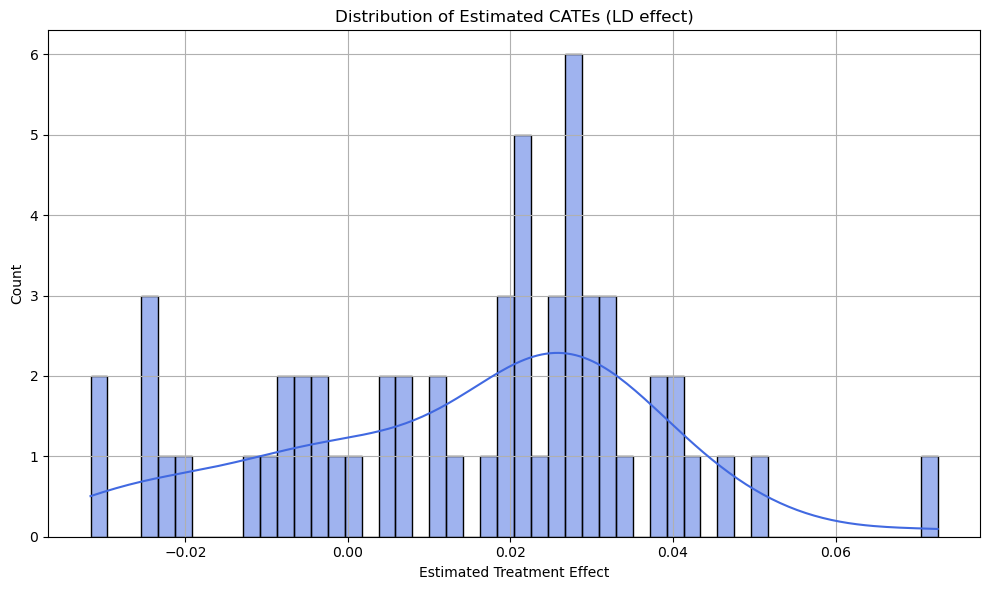

In [1]:
import os
from modules.preprocess import load_and_clean_data, prepare_variables 
from modules.dml import train_causal_forest, evaluate_ate, plot_cates, export_cate_results, learn_policy, learn_policy_forest, save_model, get_feature_importances
from sklearn.model_selection import train_test_split

df = load_and_clean_data("ed.csv", ed_daily_path="ed_daily.csv")
Outcome = 'infection_dch'
X, Y, T, feature_names = prepare_variables(df, Outcome)

X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(X, T, Y, test_size=0.2, random_state=42)

cf_model = train_causal_forest(X_train, Y_train, T_train)
results = evaluate_ate(cf_model, X_test)

print(f"\n📊 ATE Estimate: {results['ate']:.4f}")
print(f"📏 95% CI: ({results['ci'][0]:.4f}, {results['ci'][1]:.4f})")
print(f"📉 SE: {results['se']:.4f}")
print(f"🧪 P-value: {results['pval']:.4f}")

cates = cf_model.effect(X_test)
plot_cates(cates)



📊 ATE Estimate: 0.0855
📏 95% CI: (-0.0635, 0.2345)
📉 SE: 0.0760
🧪 P-value: 0.2607


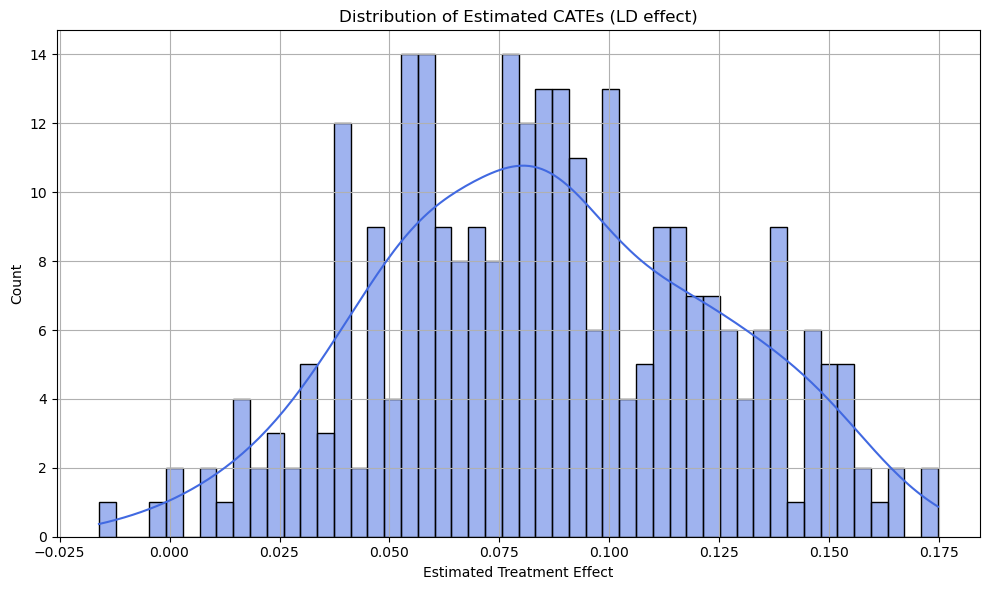

Exported all 287 patients' CATEs to cate_results\cate_results_infection_dch.csv
Model saved to models/cf_model_infection_dch.joblib


In [2]:
df = load_and_clean_data("ed.csv", ed_daily_path="ed_daily.csv")
X, Y, T, feature_names = prepare_variables(df, Outcome)

cf_model = train_causal_forest(X, Y, T)
results = evaluate_ate(cf_model, X)

print(f"\n📊 ATE Estimate: {results['ate']:.4f}")
print(f"📏 95% CI: ({results['ci'][0]:.4f}, {results['ci'][1]:.4f})")
print(f"📉 SE: {results['se']:.4f}")
print(f"🧪 P-value: {results['pval']:.4f}")

cates = cf_model.effect(X)
plot_cates(cates)
export_cate_results(X, cates, Y, T, feature_names, outcome_name=Outcome)
save_model(cf_model, path=f"models/cf_model_{Outcome}.joblib")

In [3]:
get_feature_importances(cf_model, feature_names)


Feature Importances (CausalForestDML):
balance_mean: 0.1478
icp_7am_mean: 0.0974
csf_mean: 0.0966
hb_mean: 0.0928
rr_dia_mean: 0.0849
icp_high_mean: 0.0728
rr_map_mean: 0.0705
rr_syst_mean: 0.0659
bmi: 0.0602
age: 0.0458
aneurysm_size: 0.0456
hh: 0.0342
wfns: 0.0169
aneurysm_trt: 0.0142
aneurysm_no: 0.0125
mg: 0.0121
ct_ich: 0.0069
ct_ivh: 0.0053
paresis_adm: 0.0043
ct_modfisher: 0.0042
aphasia_adm: 0.0042
sex: 0.0035
aneurysm_circulation: 0.0011
statin: 0.0002
sedation_adm: 0.0000
nimodipine: 0.0000
mrs_adm: 0.0000


balance_mean            0.147806
icp_7am_mean            0.097444
csf_mean                0.096614
hb_mean                 0.092761
rr_dia_mean             0.084930
icp_high_mean           0.072838
rr_map_mean             0.070458
rr_syst_mean            0.065875
bmi                     0.060207
age                     0.045790
aneurysm_size           0.045605
hh                      0.034236
wfns                    0.016917
aneurysm_trt            0.014226
aneurysm_no             0.012486
mg                      0.012059
ct_ich                  0.006872
ct_ivh                  0.005345
paresis_adm             0.004318
ct_modfisher            0.004223
aphasia_adm             0.004175
sex                     0.003495
aneurysm_circulation    0.001080
statin                  0.000239
sedation_adm            0.000000
nimodipine              0.000000
mrs_adm                 0.000000
dtype: float64

Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.


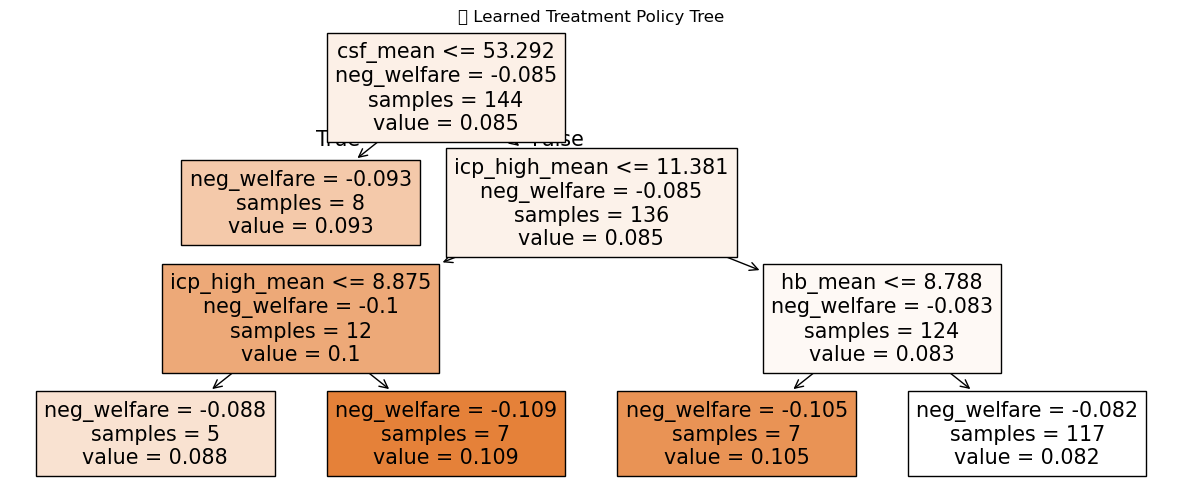

📋 Policy recommendations:
 [0 0 0 0 0 0 0 0 0 0]


In [4]:
policy_tree = learn_policy(cf_model, X)
import matplotlib.pyplot as plt

# Visualize
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 6))
plot_tree(policy_tree, feature_names=feature_names, filled=True)
plt.title("🧠 Learned Treatment Policy Tree")
plt.show()

# Binary treatment recommendations
policy_recs = policy_tree.predict(X)
print("📋 Policy recommendations:\n", policy_recs[:10])



🔬 Subgroup CATEs: aneurysm_trt
Group 1 = clipping → Mean CATE: 0.0880
Group 2 = coiling → Mean CATE: 0.0831
ΔCATE (clipping - coiling) = 0.0049
🧪 P-value: 0.2753




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



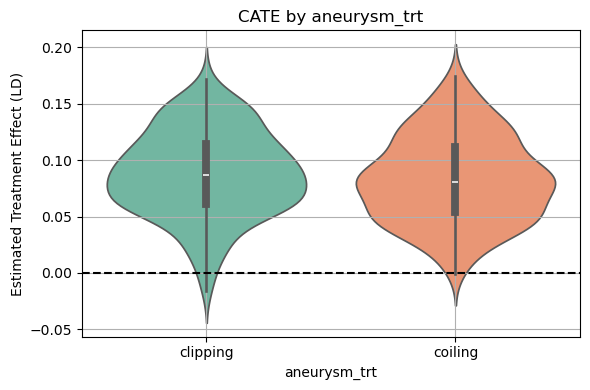


🔬 Subgroup CATEs: aneurysm_circulation
Group 1 = anterior → Mean CATE: 0.0847
Group 2 = posterior → Mean CATE: 0.0902
ΔCATE (anterior - posterior) = -0.0055
🧪 P-value: 0.4015




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



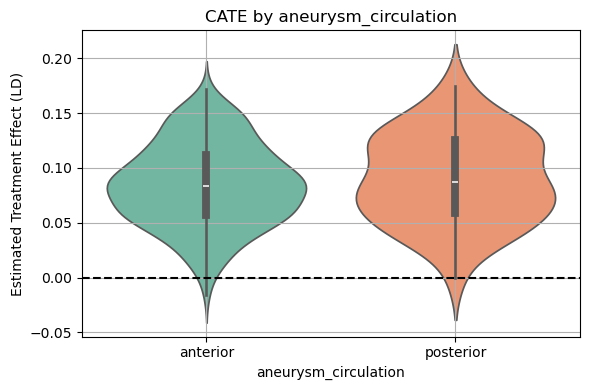


🔬 Subgroup CATEs: paresis_adm
Group 1 = yes → Mean CATE: 0.1004
Group 2 = no → Mean CATE: 0.0790
ΔCATE (yes - no) = 0.0213
🧪 P-value: 0.0000




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



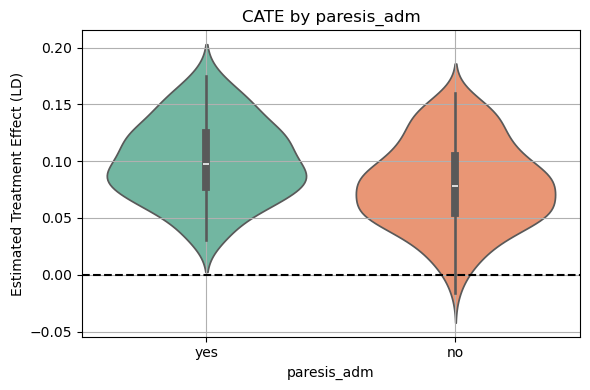


🔬 Subgroup CATEs: aphasia_adm
Group 1 = yes → Mean CATE: 0.0988
Group 2 = no → Mean CATE: 0.0789
ΔCATE (yes - no) = 0.0199
🧪 P-value: 0.0000




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



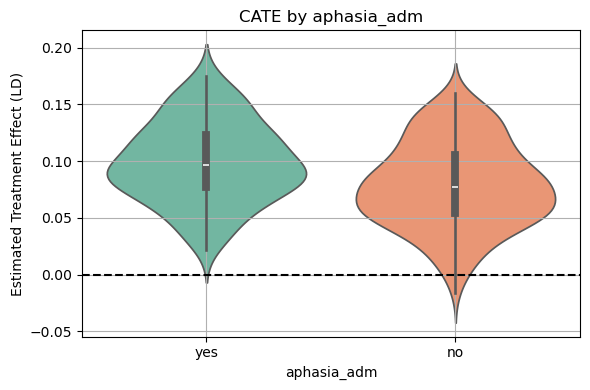


🔬 Subgroup CATEs: nimodipine
Group 1 = yes → Mean CATE: 0.0851
Group 2 = no → Mean CATE: 0.1215
ΔCATE (yes - no) = -0.0364
🧪 P-value: 0.0934




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



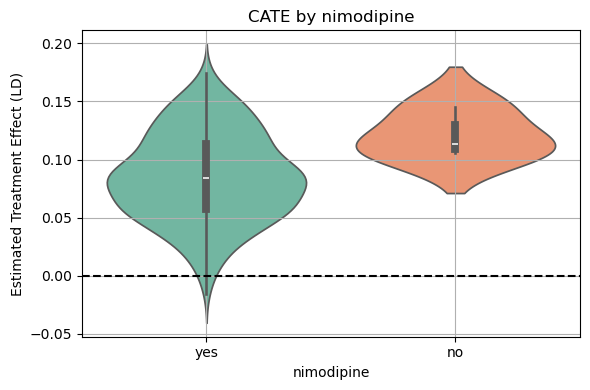



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




🔬 Subgroup CATEs: ct_ivh
Group 1 = no → Mean CATE: 0.0708
Group 2 = yes → Mean CATE: 0.0949
ΔCATE (no - yes) = -0.0241
🧪 P-value: 0.0000


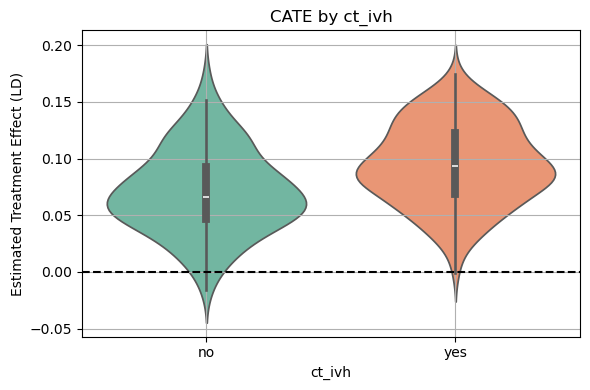


🔬 Subgroup CATEs: ct_ich
Group 1 = no → Mean CATE: 0.0800
Group 2 = yes → Mean CATE: 0.0948
ΔCATE (no - yes) = -0.0148
🧪 P-value: 0.0012




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



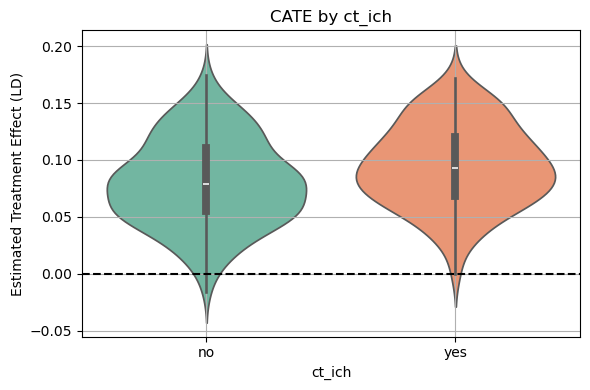

In [5]:
from modules.analysis import analyze_binary_subgroup_cates, plot_cate_vs_feature, analyze_ordinal_features, run_doubleml_analysis
import pandas as pd

binary_features = ['aneurysm_trt', 'aneurysm_circulation', 'paresis_adm', 'aphasia_adm', 'nimodipine', 'ct_ivh', 'ct_ich']
cate_df = pd.DataFrame(X, columns=feature_names)
cate_df['treatment_effect'] = cates
reverse_maps = {
    'aneurysm_trt': {1: 'coiling', 0: 'clipping'},
    'aneurysm_circulation': {1: 'anterior', 0: 'posterior'},
    'paresis_adm': {1: 'yes', 0: 'no'},
    'aphasia_adm': {1: 'yes', 0: 'no'},
    'nimodipine': {1: 'yes', 0: 'no'},
    'ct_ivh': {1: 'yes', 0: 'no'},
    'ct_ich': {1: 'yes', 0: 'no'},
    'statin': {1: 'yes', 0: 'no'},
    'mg': {1: 'yes', 0: 'no'},
    'infarct_trt': {1: 'yes', 0: 'no'},
}

analyze_binary_subgroup_cates(cate_df, df, cates, binary_features, reverse_maps)


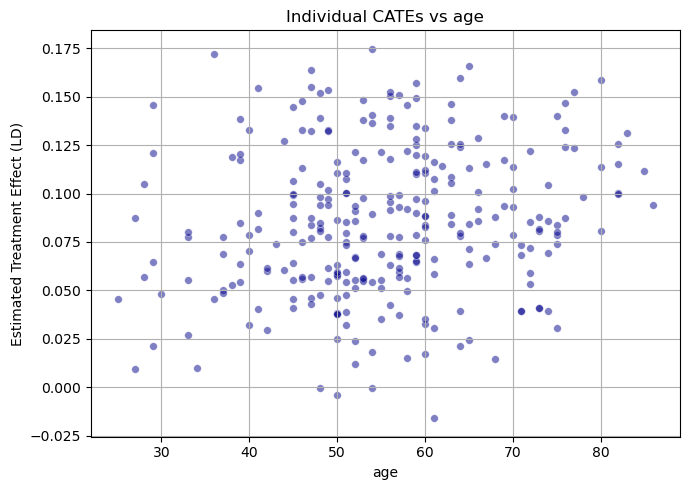

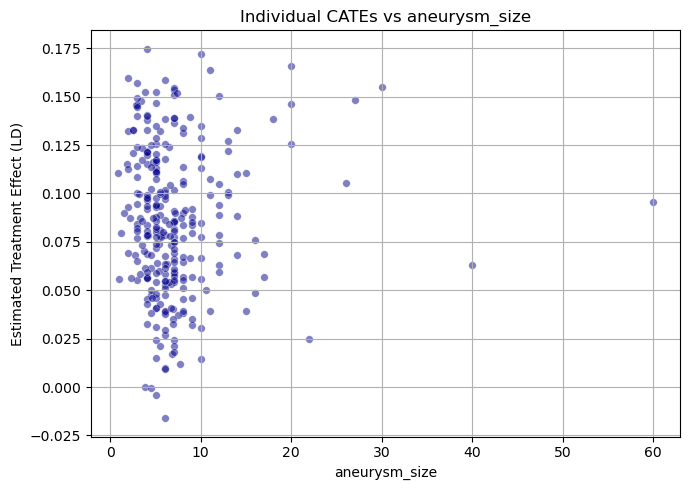

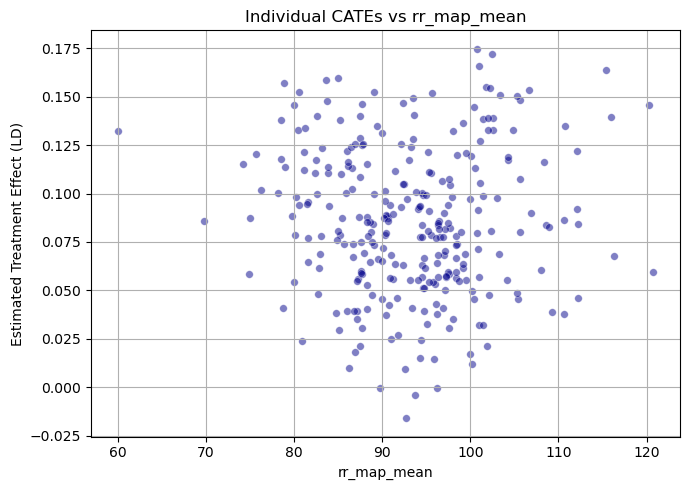

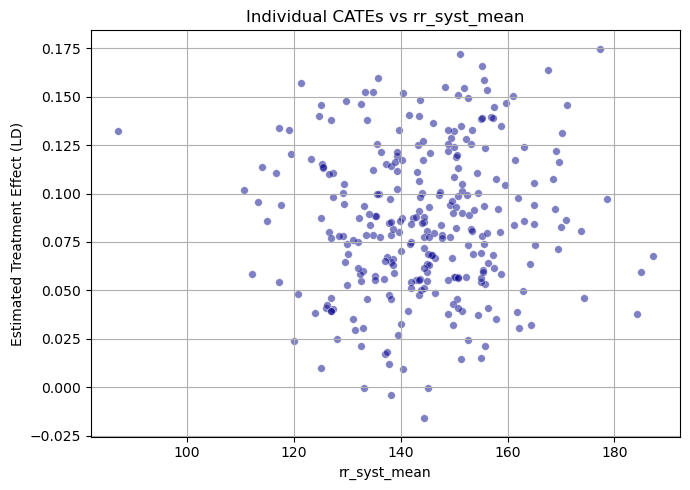

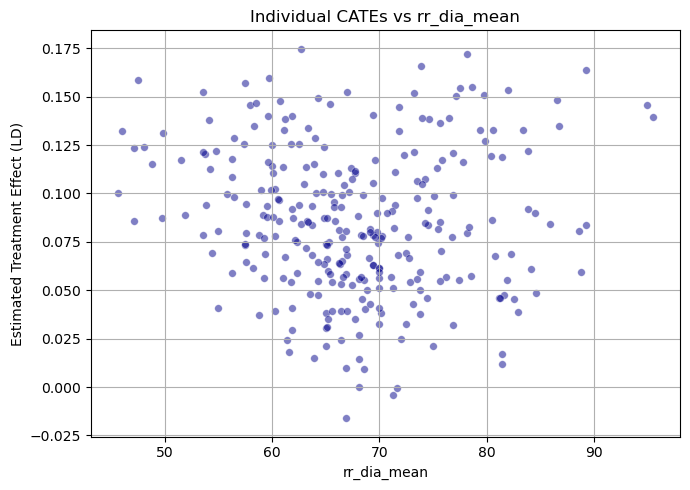

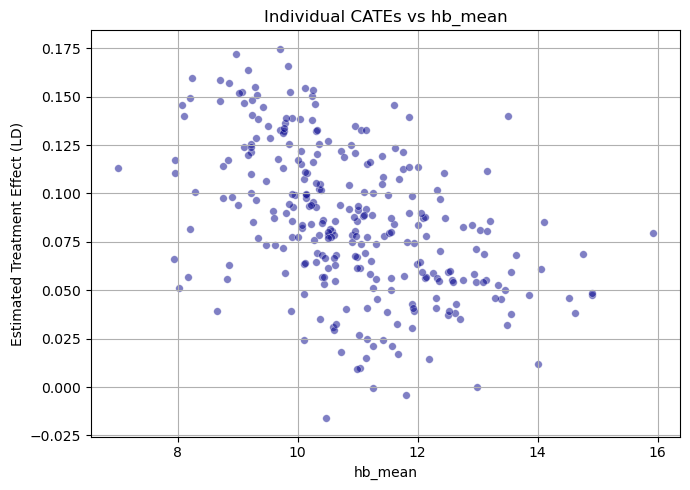

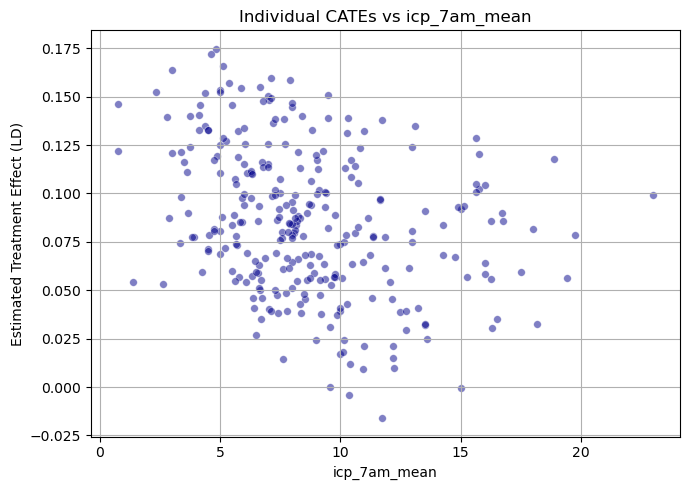

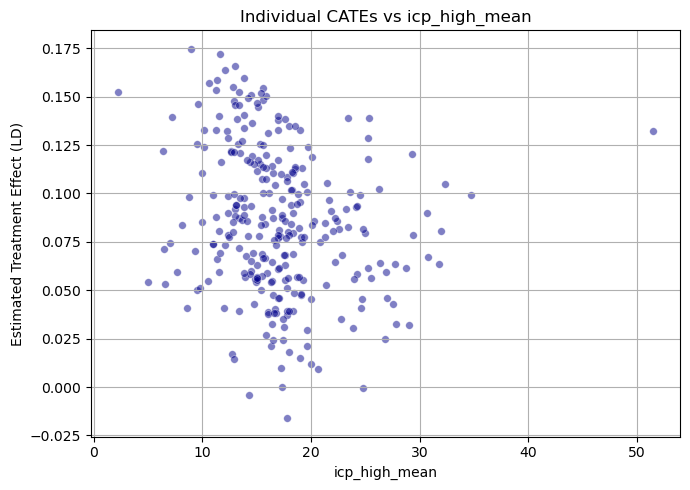

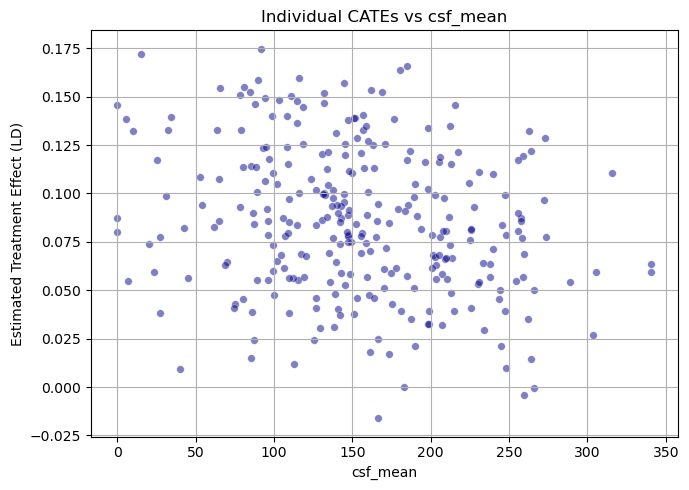

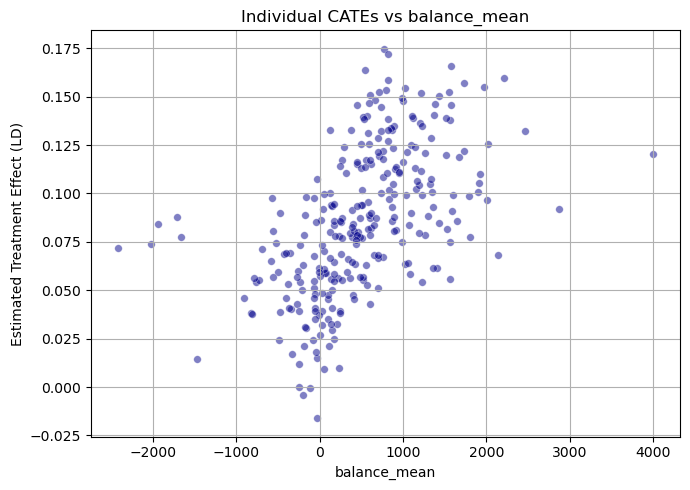

In [8]:
plot_cate_vs_feature(cate_df, 'age')
plot_cate_vs_feature(cate_df, 'aneurysm_size')
plot_cate_vs_feature(cate_df, 'rr_map_mean')
plot_cate_vs_feature(cate_df, 'rr_syst_mean')
plot_cate_vs_feature(cate_df, 'rr_dia_mean')
plot_cate_vs_feature(cate_df, 'hb_mean')
plot_cate_vs_feature(cate_df, 'icp_7am_mean')
plot_cate_vs_feature(cate_df, 'icp_high_mean')
plot_cate_vs_feature(cate_df, 'csf_mean')
plot_cate_vs_feature(cate_df, 'balance_mean')


In [7]:
dml_model = run_doubleml_analysis(X, Y, T, feature_names)


🎯 Estimated ATE via DoubleML: [0.09257988]

📏 95% Confidence Interval:
       2.5 %    97.5 %
d -0.020199  0.205359

🧪 Sensitivity Summary:
 ================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
   CI lower  theta lower    theta  theta upper  CI upper
0 -0.031638     0.062784  0.09258     0.122376  0.217267

------------------ Robustness Values ------------------
   H_0    RV (%)  RVa (%)
0  0.0  9.027112  0.00065
